In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw

from tokengt_paper_repo.tokengt_paper import TokenGTPaperGraphRegression
from tokengt_paper_experiments.pcqm4m_dataset import PCQM4MDataset
from models.add_smarts_instances import get_qm9_smarts_patterns

In [ ]:
def load_model_and_checkpoint(checkpoint_path, config):
    """Load the model from checkpoint"""
    smarts_patterns = get_qm9_smarts_patterns()
    n_substructures = len(smarts_patterns)

    data_module = PCQM4MDataset(
        batch_size=1,
        num_workers=config["num_workers"],
        d_p=config["D_P"],
        node_id_mode=config["node_id_mode"],
        smarts_patterns=smarts_patterns,
        embed_smarts=config["embed_smarts"],
        dataset_fraction=0.01,
    )

    data_module.setup()
    
    node_dim = 9 + n_substructures if config["embed_smarts"] else 9
    num_atoms = PCQM4MDataset.SINGLE_EMB_OFFSET * node_dim
    num_edges = 4 * PCQM4MDataset.SINGLE_EMB_OFFSET
    
    if config["architecture"] == "TokenGT_Paper":
        model = TokenGTPaperGraphRegression(
            num_atoms=num_atoms,
            num_edges=num_edges,
            d_p=config["D_P"],
            d=config["d"],
            num_heads=config["num_heads"],
            num_encoder_layers=config["num_encoder_layers"],
            node_id_mode=config["node_id_mode"],
            dropout=config["dropout"],
            lr=config["lr"],
            batch_size=config["batch_size"],
            weight_decay=config["weight_decay"],
            return_attention=True,
            use_interaction_bias=config["use_interaction_bias"],
        )
    elif config["architecture"] == "TokenGT_Paper_Sum":
        model = TokenGTPaperGraphRegression(
            num_atoms=num_atoms,
            num_edges=num_edges,
            d_p=config["D_P"],
            d=config["d"],
            num_heads=config["num_heads"],
            num_encoder_layers=config["num_encoder_layers"],
            node_id_mode=config["node_id_mode"],
            dropout=config["dropout"],
            lr=config["lr"],
            batch_size=config["batch_size"],
            weight_decay=config["weight_decay"],
            substructure_mode="sum",
            n_substructures=n_substructures,
            return_attention=True,
            use_interaction_bias=config["use_interaction_bias"],
        )
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    
    return model, data_module

config = {
    "architecture": "TokenGT_Paper_Sum",
    "dataset": "PCQM4M",
    "embed_smarts": False,
    "node_id_mode": "orf",
    "D_P": 16,
    "num_heads": 16,
    "d": 128,
    "num_encoder_layers": 4,
    "epochs": 100,
    "batch_size": 512,
    "lr": 0.005,
    "num_workers": 8,
    "weight_decay": 0.01,
    "dropout": 0.1,
    "checkpointing": False,
    "seed": 1,
    "use_interaction_bias": False
}

checkpoint_path = "tokengt_experiments/model_analysis/tgt_s_orf-val_loss=0.1832.ckpt"
# checkpoint_path = "tokengt_experiments/model_analysis/tgt_s_lap-val_loss=0.1356.ckpt"
tgts_model, data_module = load_model_and_checkpoint(checkpoint_path, config)

checkpoint_path = "tokengt_experiments/model_analysis/tgt_orf-val_loss=0.1914.ckpt"
# checkpoint_path = "tokengt_experiments/model_analysis/tgt_lap-val_loss=0.1382.ckpt"
config["architecture"] = "TokenGT_Paper"
tgt_model, _ = load_model_and_checkpoint(checkpoint_path, config)
    

Using 1.0% of dataset: train=10, val=1000, test=147037
Using 1.0% of dataset: train=10, val=1000, test=147037


In [4]:
samples = []
for batch in data_module.val_dataloader():
    samples.append(batch)
    if len(samples) > 1000:
        break

print(samples)

[DataBatch(x=[17, 9], edge_index=[2, 36], edge_attr=[36, 3], y=[1], smiles=[1], substructure_instances=[0, 8], n_substructure_instances=[1], node_data=[17, 9], edge_data=[36, 3], in_degree=[17], out_degree=[17], lap_eigvec=[17, 16], batch=[17], ptr=[2]), DataBatch(x=[10, 9], edge_index=[2, 22], edge_attr=[22, 3], y=[1], smiles=[1], substructure_instances=[0, 8], n_substructure_instances=[1], node_data=[10, 9], edge_data=[22, 3], in_degree=[10], out_degree=[10], lap_eigvec=[10, 16], batch=[10], ptr=[2]), DataBatch(x=[17, 9], edge_index=[2, 34], edge_attr=[34, 3], y=[1], smiles=[1], substructure_instances=[7, 8], n_substructure_instances=[1], node_data=[17, 9], edge_data=[34, 3], in_degree=[17], out_degree=[17], lap_eigvec=[17, 16], batch=[17], ptr=[2]), DataBatch(x=[16, 9], edge_index=[2, 34], edge_attr=[34, 3], y=[1], smiles=[1], substructure_instances=[6, 8], n_substructure_instances=[1], node_data=[16, 9], edge_data=[34, 3], in_degree=[16], out_degree=[16], lap_eigvec=[16, 16], batch

Number of nodes: 16
Number of edges: 34
Number of substructures: 4
Substructure instances: tensor([[ 3,  4,  5,  6,  7,  8,  9, -1],
        [ 6, 12, 11, -1, -1, -1, -1, -1],
        [ 7, 11, 12, 13, -1, -1, -1, -1],
        [ 8,  2,  3, -1, -1, -1, -1, -1]])
Node data: tensor([[   6,  512, 1025, 1541, 2048, 2560, 3072, 3584, 4096],
        [   5,  512, 1026, 1541, 2048, 2560, 3072, 3584, 4096],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3584, 4097],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3584, 4097],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3585, 4097],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097],
        [   5,  514, 1028, 1541, 2048, 2560, 3074, 3584, 4097],
        [   6,  512, 1026

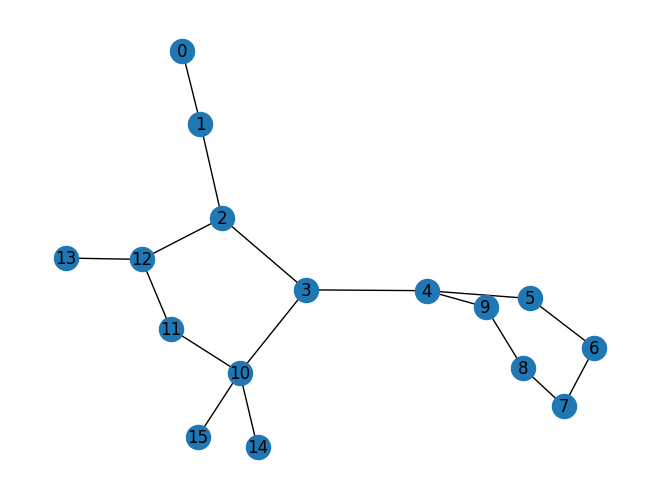

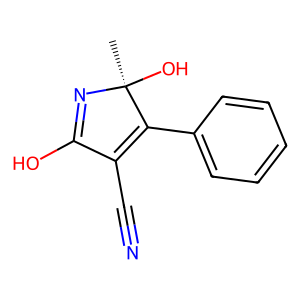

In [33]:
sample_idx = 4
sample = samples[sample_idx]

n_nodes = sample.node_data.shape[0]
n_edges = sample.edge_data.shape[0]
n_substructures = sample.substructure_instances.shape[0]
substructure_start = 1 + n_nodes + n_edges

print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Number of substructures: {n_substructures}")
print(f"Substructure instances: {sample.substructure_instances}")
print(f"Node data: {sample.node_data}")
print(f"Smiles: {sample.smiles[0]}")

tgts_pred, tgts_maps = tgts_model(sample)
tgt_pred, tgt_maps = tgt_model(sample)

tgts_attn = [tgts_maps["maps"][i].detach().numpy() for i in range(len(tgts_maps["maps"]))]
tgts_attn = np.array(tgts_attn).squeeze()

tgt_attn = [tgt_maps["maps"][i].detach().numpy() for i in range(len(tgt_maps["maps"]))]
tgt_attn = np.array(tgt_attn).squeeze()

G = nx.Graph()
G.add_edges_from(sample.edge_index.T.tolist())
nx.draw(G, with_labels=True)
plt.show()

mol = Chem.MolFromSmiles(sample.smiles[0])
img = Draw.MolToImage(mol, size=(300, 300))
img

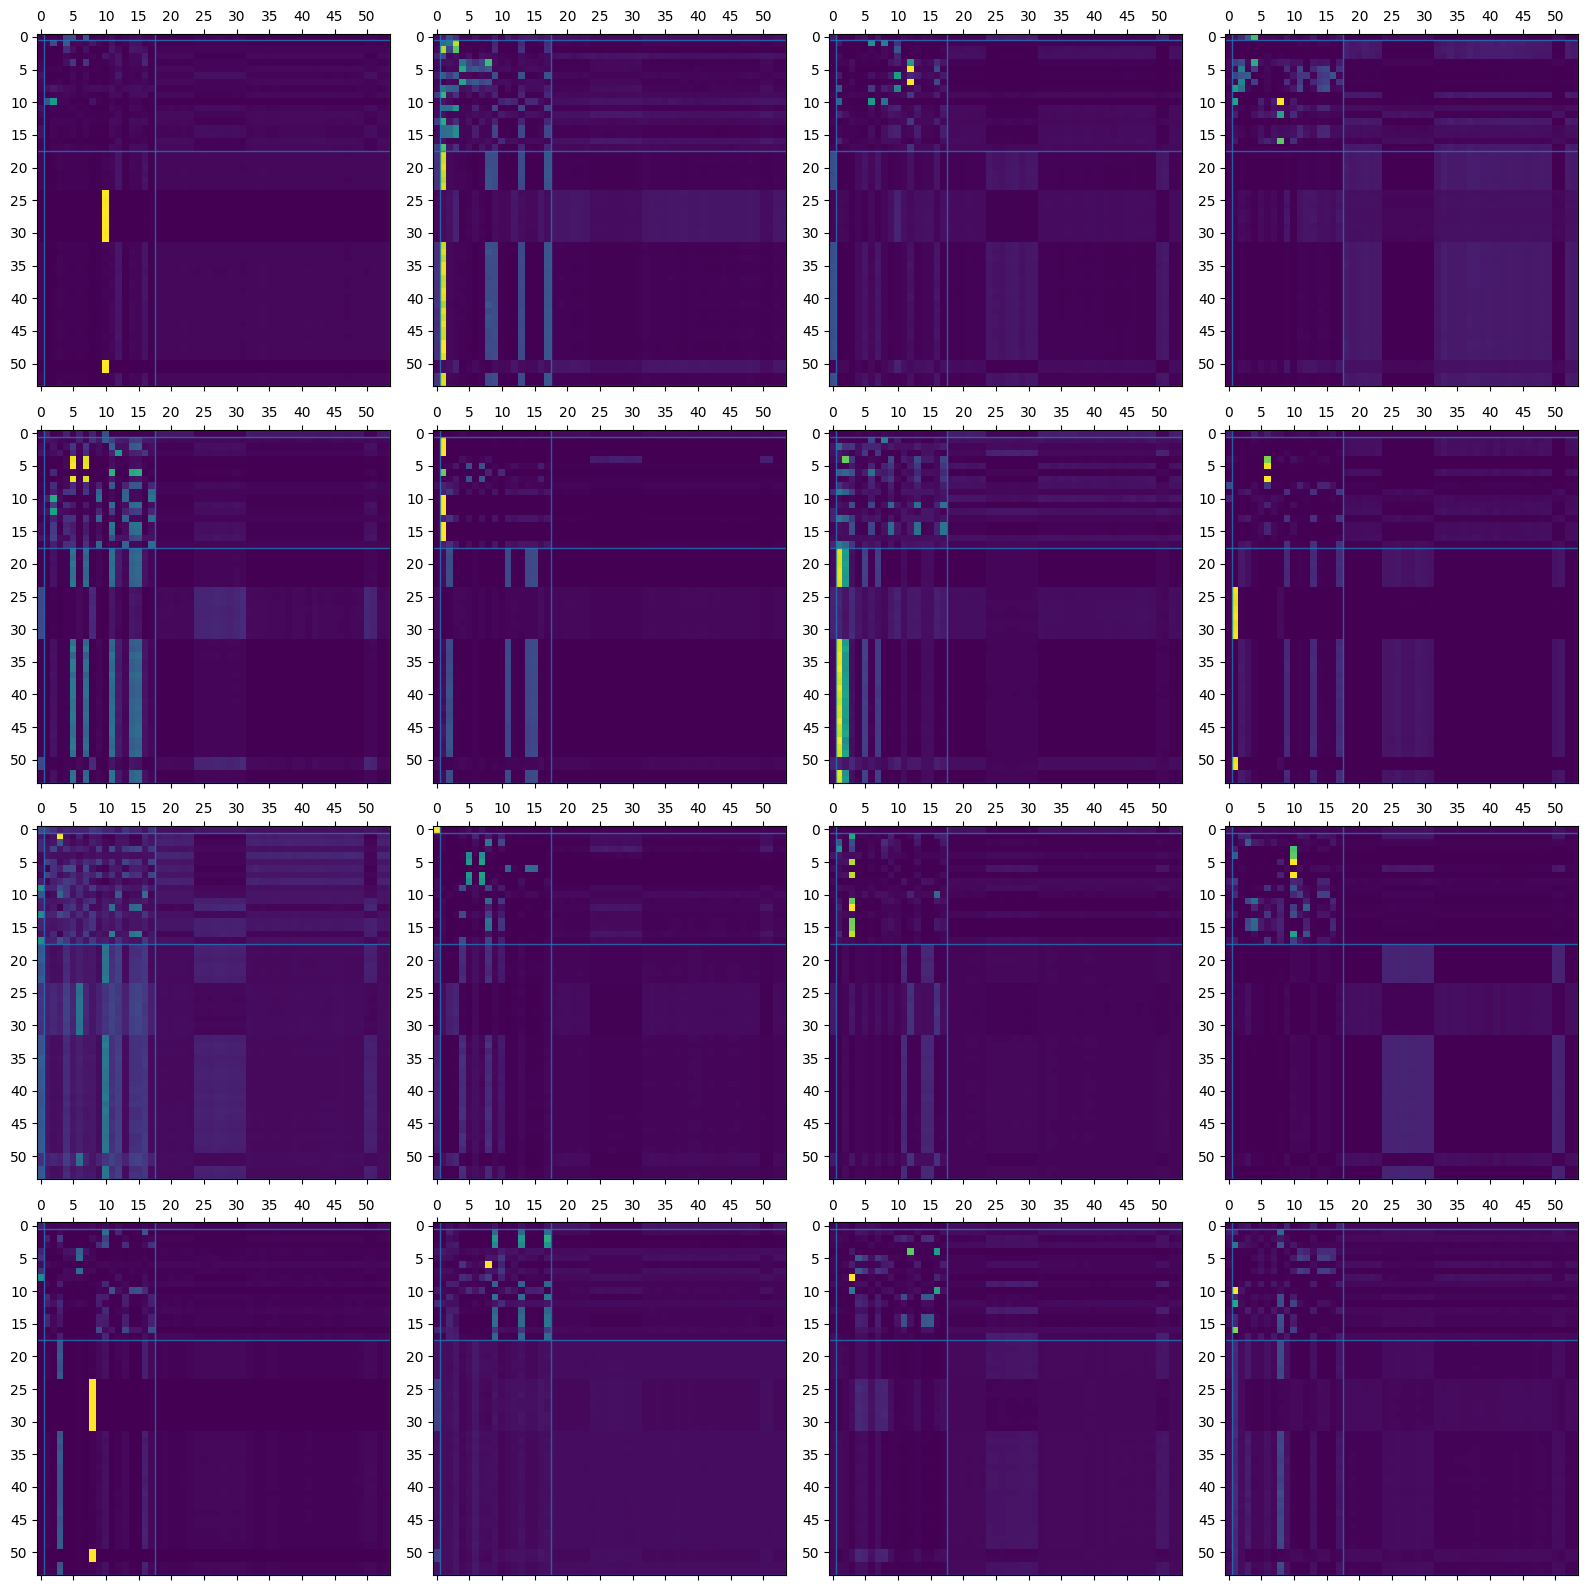

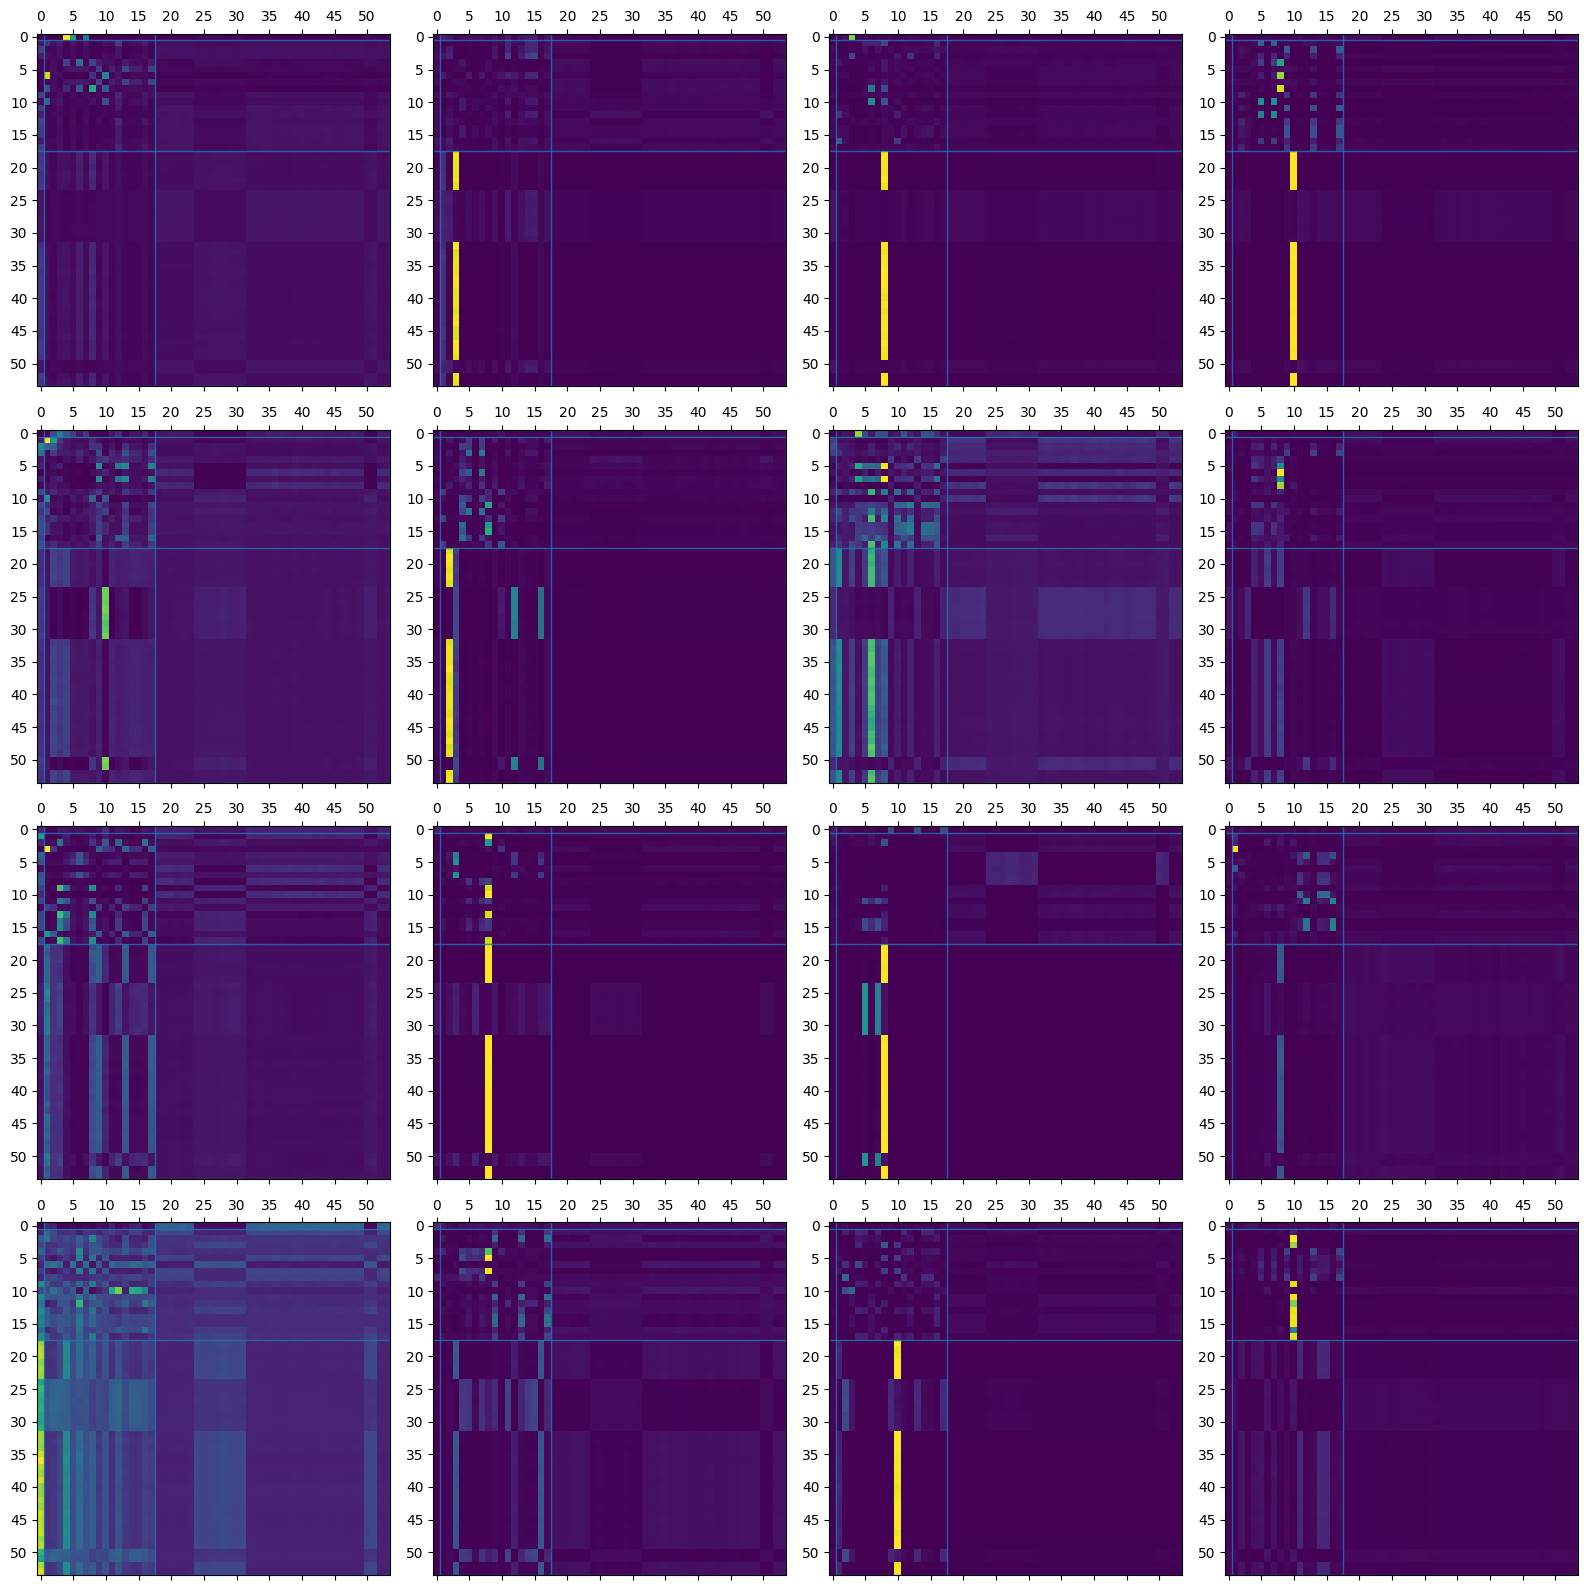

In [24]:
import matplotlib.pyplot as plt

def plot_attention_with_token_bars_from_sample(maps, sample, layer_idx=0):

    node_start = 1 # graph token
    edge_start = node_start + n_nodes
    substructure_start = edge_start + n_edges
    
    num_heads = len(maps["maps"][0])

    fig, axs = plt.subplots(num_heads // 4, 4, figsize=(16, 16))
    for head in range(num_heads):
        ax = axs[head // 4, head % 4]
        
        attn_matrix = maps["maps"][layer_idx][head][0].detach().numpy()
        im = ax.matshow(attn_matrix, cmap="viridis")

        ax.set_xticks(np.arange(0, attn_matrix.shape[1], 5))
        ax.set_yticks(np.arange(0, attn_matrix.shape[0], 5))
        
        ax.axvline(x=node_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=node_start-0.5, linewidth=1, alpha=0.8)
        
        ax.axvline(x=edge_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=edge_start-0.5, linewidth=1, alpha=0.8)
        
        ax.axvline(x=substructure_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=substructure_start-0.5, linewidth=1, alpha=0.8)
    
    plt.tight_layout()
    
    return fig

fig = plot_attention_with_token_bars_from_sample(tgts_maps, sample, layer_idx=0)
plt.show()
fig = plot_attention_with_token_bars_from_sample(tgt_maps, sample, layer_idx=0)
plt.show()

In [93]:
def get_row_normalized_attn(attn, row_start, row_end, col_start, col_end):
    attn = attn[:, :, :, col_start:col_end]
    attn = attn / attn.sum(axis=3, keepdims=True)
    return attn[:, :, row_start:row_end, :]

def get_attn_stats(attn):
    node_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, substructure_start).reshape(-1, substructure_start-1).mean(axis=0)
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    return node_mean_attn[constituent_node_set].mean(), node_mean_attn[non_constituent_nodes].mean()

def get_st_updated_attn(attn):
    node_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, attn.shape[3]).reshape(-1, attn.shape[3]-1).mean(axis=0)
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    token_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, attn.shape[3]).reshape(-1, attn.shape[3]-1).mean(axis=0)[n_nodes+n_edges:]
    st_by_node_attn = np.zeros(n_nodes)
    for i, subs in enumerate(sample.substructure_instances):
        safe_indices = subs[1:][subs[1:] != -1]
        st_by_node_attn[safe_indices] += token_mean_attn[i] / len(safe_indices)
    updated_attn = node_mean_attn[:n_nodes] + st_by_node_attn
    return updated_attn[constituent_node_set].mean(), updated_attn[non_constituent_nodes].mean()


tgts_consts = []
tgts_non_consts = []
tgts_st = []
tgt_consts = []
tgts_updated_consts = []
tgts_updated_non_consts = []
for sample_idx in range(1000):
    sample = samples[sample_idx]

    n_nodes = sample.node_data.shape[0]
    n_edges = sample.edge_data.shape[0]
    n_substructures = sample.substructure_instances.shape[0]
    substructure_start = 1 + n_nodes + n_edges

    if n_substructures == 0:
        continue
    
    tgts_pred, tgts_maps = tgts_model(sample)
    tgt_pred, tgt_maps = tgt_model(sample)

    tgts_attn = [tgts_maps["maps"][i].detach().numpy() for i in range(len(tgts_maps["maps"]))]
    tgts_attn = np.array(tgts_attn).squeeze()

    tgt_attn = [tgt_maps["maps"][i].detach().numpy() for i in range(len(tgt_maps["maps"]))]
    tgt_attn = np.array(tgt_attn).squeeze()

    tgts_const, tgts_non_const = get_attn_stats(tgts_attn)
    tgt_const, tgt_non_const = get_attn_stats(tgt_attn)
    tgts_updated_const, tgts_updated_non_const = get_st_updated_attn(tgts_attn)

    tgts_consts.append(tgts_const)
    tgts_non_consts.append(tgts_non_const)
    tgt_consts.append(tgt_const)
    tgt_non_consts.append(tgt_non_const)
    tgts_updated_consts.append(tgts_updated_const)
    tgts_updated_non_consts.append(tgts_updated_non_const)

print(f"TGTS constituent node set mean attn: {np.mean(tgts_consts)}")
print(f"TGTS non constituent node set mean attn: {np.nanmean(tgts_non_consts)}")
print(f"TGTS updated constituent node set mean attn: {np.mean(tgts_updated_consts)}")
print(f"TGTS updated non constituent node set mean attn: {np.nanmean(tgts_updated_non_consts)}")
print("--------------------------------")
print(f"TGT constituent node set mean attn: {np.mean(tgt_consts)}")
print(f"TGT non constituent node set mean attn: {np.nanmean(tgt_non_consts)}")


/var/folders/k8/qybls4_s35z08vdl10p0fc780000gn/T/ipykernel_62355/3893655573.py:10: RuntimeWarning: Mean of empty slice.
  return node_mean_attn[constituent_node_set].mean(), node_mean_attn[non_constituent_nodes].mean()
/var/folders/k8/qybls4_s35z08vdl10p0fc780000gn/T/ipykernel_62355/3893655573.py:22: RuntimeWarning: Mean of empty slice.
  return updated_attn[constituent_node_set].mean(), updated_attn[non_constituent_nodes].mean()


TGTS constituent node set mean attn: 0.03163255751132965
TGTS non constituent node set mean attn: 0.03043525665998459
TGTS updated constituent node set mean attn: 0.0413408138806237
TGTS updated non constituent node set mean attn: 0.027714674120240125
--------------------------------
TGT constituent node set mean attn: 0.03631851077079773
TGT non constituent node set mean attn: 0.0272857453674078
